<a href="https://colab.research.google.com/github/RagaSandhiya05/LLM-From-Scratch/blob/main/12_Mini_GPT(NovaGPT).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**MINI GPT**

**Import Libraries**

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math
import matplotlib.pyplot as plt
torch.manual_seed(42)
print("PyTorch Version : " , torch.__version__)

PyTorch Version :  2.11.0+cpu


**Tiny Training Corpus**

In [3]:
text = """
artificial intelligence is changing the world
machine learning makes computers learn
deep learning is a part of artificial intelligence
python is popular for machine learning
large language models generate human like text
transformers power modern language models
neural network learn patterns from data
"""
print("Training Corpus :\n")
print(text)

Training Corpus :


artificial intelligence is changing the world
machine learning makes computers learn
deep learning is a part of artificial intelligence
python is popular for machine learning
large language models generate human like text
transformers power modern language models
neural network learn patterns from data



**Tokenization**

In [4]:
tokens = text.lower().split()
print("Total Tokens : " , len(tokens))
print("\nFirst 30 Tokens :\n")
print(tokens[:30])

Total Tokens :  43

First 30 Tokens :

['artificial', 'intelligence', 'is', 'changing', 'the', 'world', 'machine', 'learning', 'makes', 'computers', 'learn', 'deep', 'learning', 'is', 'a', 'part', 'of', 'artificial', 'intelligence', 'python', 'is', 'popular', 'for', 'machine', 'learning', 'large', 'language', 'models', 'generate', 'human']


**Build Vocabulary**

In [5]:
vocab = sorted(set(tokens))
vocab_size = len(vocab)

word_to_id = {
    word : idx
    for idx , word in enumerate(vocab)
}

id_to_word = {
    idx : word
    for word , idx in word_to_id.items()
}

print("Vocabulary Size :" , vocab_size)
print("\nVocabulary :\n")
print(vocab)

Vocabulary Size : 33

Vocabulary :

['a', 'artificial', 'changing', 'computers', 'data', 'deep', 'for', 'from', 'generate', 'human', 'intelligence', 'is', 'language', 'large', 'learn', 'learning', 'like', 'machine', 'makes', 'models', 'modern', 'network', 'neural', 'of', 'part', 'patterns', 'popular', 'power', 'python', 'text', 'the', 'transformers', 'world']


**Encode Tokens**

In [6]:
encoded = [
    word_to_id[word]
    for word in tokens
]
print("Encoded Tokens :\n")
print(encoded)

Encoded Tokens :

[1, 10, 11, 2, 30, 32, 17, 15, 18, 3, 14, 5, 15, 11, 0, 24, 23, 1, 10, 28, 11, 26, 6, 17, 15, 13, 12, 19, 8, 9, 16, 29, 31, 27, 20, 12, 19, 22, 21, 14, 25, 7, 4]


**Create Training Sequences**

In [7]:
context_size = 4
X = []
Y = []
for i in range(len(encoded) - context_size) :
  X.append(encoded[i : i + context_size])
  Y.append(encoded[i + context_size])
X = torch.tensor(X)
Y = torch.tensor(Y)
print("Input Shape : " , X.shape)
print("Target Shape : " , Y.shape)
print("\nSample Input IDs : ")
print(X[0])
print("\nSample Target ID : ")
print(Y[0])
print("\nDecoded Example : ")
context_words = [
    id_to_word[idx.item()]
    for idx in X[0]
]
target_word = id_to_word[Y[0].item()]
print("Context : " , context_words)
print("Target : " , target_word)

Input Shape :  torch.Size([39, 4])
Target Shape :  torch.Size([39])

Sample Input IDs : 
tensor([ 1, 10, 11,  2])

Sample Target ID : 
tensor(30)

Decoded Example : 
Context :  ['artificial', 'intelligence', 'is', 'changing']
Target :  the


**Positional Encoding**

In [8]:
import math
import torch
import torch.nn as nn

class PositionalEncoding(nn.Module) :

    def __init__(self , embedding_dim , max_length) :
        super().__init__()

        pe = torch.zeros(max_length , embedding_dim)

        position = torch.arange(0 , max_length).unsqueeze(1).float()

        div_term = torch.exp(
            torch.arange(0, embedding_dim, 2).float()
            * (-math.log(10000.0) / embedding_dim)
        )

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        pe = pe.unsqueeze(0)

        self.register_buffer("pe" , pe)

    def forward(self, x) :

        x = x + self.pe[: , :x.size(1)]

        return x

**Transformer Block**

In [9]:
class TransformerBlock(nn.Module) :

    def __init__(self , embedding_dim , num_heads , ff_dim) :
        super().__init__()

        self.attention = nn.MultiheadAttention(
            embedding_dim ,
            num_heads ,
            batch_first = True
        )

        self.norm1 = nn.LayerNorm(embedding_dim)

        self.ffn = nn.Sequential(
            nn.Linear(embedding_dim, ff_dim) ,
            nn.ReLU() ,
            nn.Linear(ff_dim , embedding_dim)
        )

        self.norm2 = nn.LayerNorm(embedding_dim)

    def forward(self, x) :

        seq_length = x.size(1)

        mask = torch.triu(
            torch.ones(seq_length, seq_length) ,
            diagonal = 1
        ).bool().to(x.device)

        attention_output, _ = self.attention(
            x ,
            x ,
            x ,
            attn_mask=mask
        )

        x = self.norm1(x + attention_output)

        ff_output = self.ffn(x)

        x = self.norm2(x + ff_output)

        return x

**Mini GPT Model**

In [16]:
class MiniGPT(nn.Module):
    def __init__(
        self ,
        vocab_size ,
        embedding_dim ,
        num_heads ,
        ff_dim ,
        num_layers ,
        max_length
    ) :

        super().__init__()

        self.embedding = nn.Embedding(
            vocab_size ,
            embedding_dim
        )

        self.position = PositionalEncoding(
            embedding_dim ,
            max_length
        )

        self.blocks = nn.Sequential(

            *[
                TransformerBlock(
                    embedding_dim ,
                    num_heads ,
                    ff_dim
                )

                for _ in range(num_layers)
            ]

        )

        self.output = nn.Linear(
            embedding_dim ,
            vocab_size
        )

    def forward(self, x) :

        x = self.embedding(x)

        x = self.position(x)

        x = self.blocks(x)

        x = self.output(x)

        x = x[: , -1 , :]

        return x

**Create Model**

In [17]:
embedding_dim = 32

num_heads = 4

ff_dim = 64

num_layers = 2

max_length = context_size

model = MiniGPT(

    vocab_size ,

    embedding_dim ,

    num_heads ,

    ff_dim ,

    num_layers ,

    max_length

)

print(model)

MiniGPT(
  (embedding): Embedding(33, 32)
  (position): PositionalEncoding()
  (blocks): Sequential(
    (0): TransformerBlock(
      (attention): MultiheadAttention(
        (out_proj): NonDynamicallyQuantizableLinear(in_features=32, out_features=32, bias=True)
      )
      (norm1): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
      (ffn): Sequential(
        (0): Linear(in_features=32, out_features=64, bias=True)
        (1): ReLU()
        (2): Linear(in_features=64, out_features=32, bias=True)
      )
      (norm2): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
    )
    (1): TransformerBlock(
      (attention): MultiheadAttention(
        (out_proj): NonDynamicallyQuantizableLinear(in_features=32, out_features=32, bias=True)
      )
      (norm1): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
      (ffn): Sequential(
        (0): Linear(in_features=32, out_features=64, bias=True)
        (1): ReLU()
        (2): Linear(in_features=64, out_features=32, bias=T

**Loss Function & Optimizer**

In [18]:
loss_function = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(
    model.parameters() ,
    lr = 0.01
)
print("Loss Function : " , loss_function)
print("Optimizer : " , optimizer)

Loss Function :  CrossEntropyLoss()
Optimizer :  Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.01
    maximize: False
    weight_decay: 0
)


**Forward Pass Test**

In [19]:
sample_output = model(X[:2])

print("Input Shape : " , X[:2].shape)

print("Output Shape : " , sample_output.shape)

print("\nVocabulary Size : " , vocab_size)

Input Shape :  torch.Size([2, 4])
Output Shape :  torch.Size([2, 33])

Vocabulary Size :  33


**Training Loop**

In [20]:
epochs = 300
loss_history = []
model.train()
for epoch in range(epochs) :
  optimizer.zero_grad()
  output = model(X)
  loss = loss_function(output , Y)
  loss.backward()
  optimizer.step()
  loss_history.append(loss.item())
  if(epoch + 1) % 25 == 0 :
    print(f"Epoch {epoch + 1 : 3d} | Loss = {loss.item() : .4f}")

Epoch  25 | Loss =  0.0257
Epoch  50 | Loss =  0.0034
Epoch  75 | Loss =  0.0020
Epoch  100 | Loss =  0.0016
Epoch  125 | Loss =  0.0013
Epoch  150 | Loss =  0.0011
Epoch  175 | Loss =  0.0009
Epoch  200 | Loss =  0.0008
Epoch  225 | Loss =  0.0007
Epoch  250 | Loss =  0.0006
Epoch  275 | Loss =  0.0005
Epoch  300 | Loss =  0.0005


**Plot Training Loss**

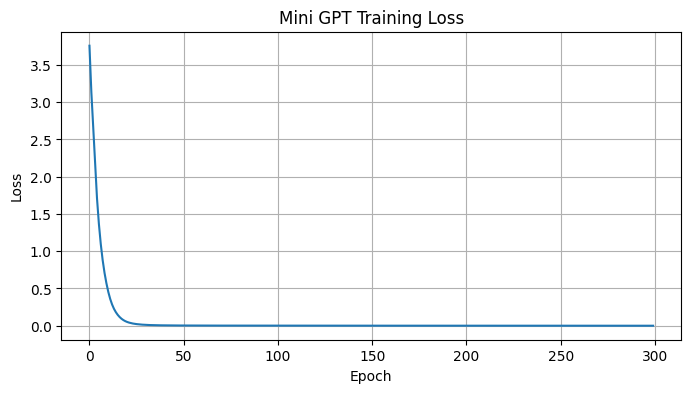

In [22]:
plt.figure(figsize = (8 , 4))
plt.plot(loss_history)
plt.title("Mini GPT Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

**Temperature Sampling**

In [23]:
def sample(logits , temperature = 1.0) :
  logits = logits / temperature
  probabilities = F.softmax(logits , dim = -1)
  prediction = torch.multinomial(
      probabilities ,
      1
  )
  return prediction.item()

**Text Generation**

In [24]:
def generate_text(prompt , max_new_tokens = 10 , temperature = 1.0) :
  model.eval()
  words = prompt.lower().split()
  for _ in range(max_new_tokens) :
    context = words[-context_size :]
    while len(context) < context_size :
      context.insert(0 , "<pad>")
    ids = []
    for word in context :
      if word in word_to_id :
        ids.append(word_to_id[word])
      else :
        ids.append(0)
    x = torch.tensor([ids])
    with torch.no_grad() :
      output = model(x)
    next_id = sample(
        output.squeeze() ,
        temperature
    )
    next_word = id_to_word[next_id]
    words.append(next_word)
  return " ".join(words)

**Generate Text**

In [28]:
print(generate_text(
    "artificial intelligence" ,
    temperature = 0.8
))

print()

print(generate_text(
    "machine learning" ,
    temperature = 1.0
))

print()

print(generate_text(
    "python" ,
    temperature = 0.7
))

artificial intelligence python is popular for machine learning large language models generate

machine learning large language models generate human like text transformers power modern

python is learn patterns from data learn patterns from data popular


**Interactive GPT**

In [32]:
while True :
  prompt = input("Enter Prompt (type 'exit' to stop) : ")
  if prompt.lower() == "exit" :
    break
  print()
  print(generate_text(
      prompt ,
      temperature = 0.8
  ))
  print()

Enter Prompt (type 'exit' to stop) : artificial

artificial intelligence python is popular for machine learning large language models

Enter Prompt (type 'exit' to stop) : deep learning

deep learning is a part of artificial intelligence python is popular for

Enter Prompt (type 'exit' to stop) : transformers

transformers power modern language models neural network learn patterns from data

Enter Prompt (type 'exit' to stop) : machine learning

machine learning a part of artificial intelligence python is popular for machine

Enter Prompt (type 'exit' to stop) : neural networks

neural networks part of artificial intelligence python is popular for machine learning

Enter Prompt (type 'exit' to stop) : exit


**Model Summary**

In [33]:
print("=" * 50)
print("Mini GPT")
print("=" * 50)
print(f"Vocabulary Size : {vocab_size}")
print(f"Embedding Dimension : {embedding_dim}")
print(f"Attention Heads : {num_heads}")
print(f"Transformer Blocks : {num_layers}")
print(f"Context_length : {context_size}")
print(f"Training Samples : {len(X)}")
print("=" * 50)

Mini GPT
Vocabulary Size : 33
Embedding Dimension : 32
Attention Heads : 4
Transformer Blocks : 2
Context_length : 4
Training Samples : 39
